# 103.8. Multi-coadd mosaic cutouts

<div style="max-width:300px; float: left; margin-right: 1em">

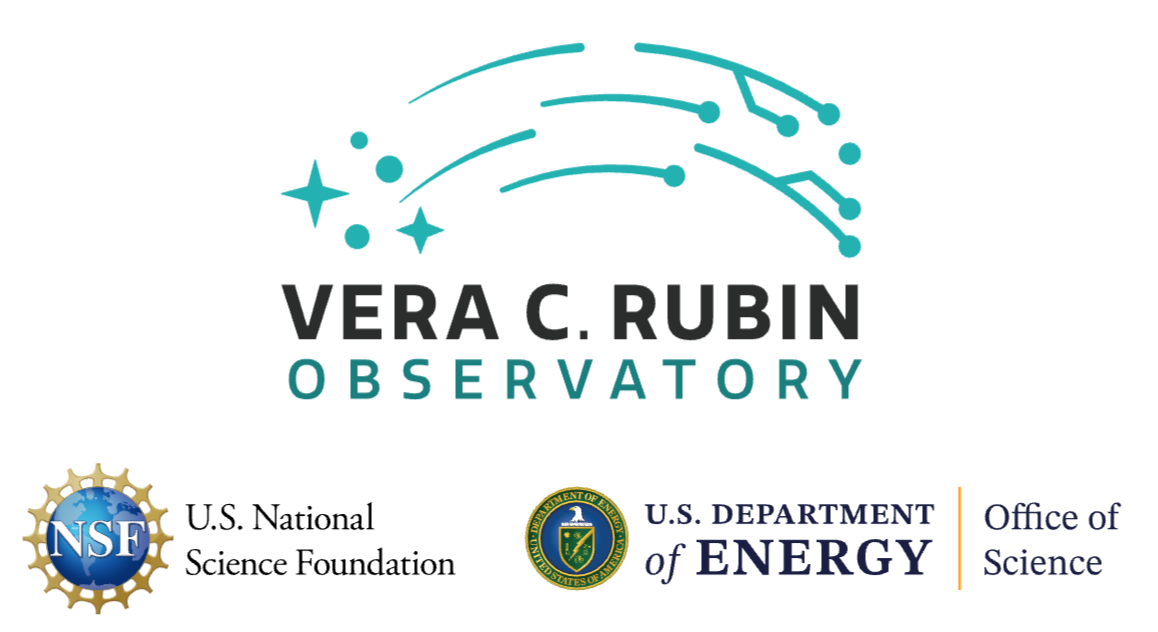

</div>

For the Rubin Science Platform at data.lsst.cloud.\
Data Release: [Data Preview 2](https://dp2.lsst.io/)\
Container Size: Large\
LSST Science Pipelines version: r30.0.11\
Last verified to run: 2026-09-10\
Repository: [github.com/lsst/tutorial-notebooks](https://github.com/lsst/tutorial-notebooks)\
DOI: [10.11578/rubin/dc.20250909.20](https://doi.org/10.11578/rubin/dc.20250909.20)

**Learning objective:** Create a large, custom `deep_coadd` cutout that spans multiple patches (and possibly tracts).

**LSST data products:** `deep_coadd`.

**Packages:** `lsst.daf.butler`, `lsst.ip.diffim.GetTemplateTask`, `lsst.pipe.tasks.makeDiscreteSkyMap`, `lsst.pipe.base`.

**Credit:** Originally developed by Andrés A. Plazas Malagón and the Rubin Community Science team with input from Nate Lust. Adapted for DP2 by the Rubin Community Science team.
Please consider acknowledging them if this notebook is used for the preparation of journal articles, software releases, or other notebooks.

**Get Support:**
Everyone is encouraged to ask questions or raise issues in the
<a href="https://community.lsst.org/c/support">Support Category</a>
of the Rubin Community Forum.
Rubin staff will respond to all questions posted there.

## 1. Introduction

This tutorial demonstrates how to create a large, custom cutout from the LSST `deep_coadd` images using the Rubin Science Platform (RSP) and the LSST Science Pipelines, defining an arbitrary sky region larger than a single coadd patch.
The workflow follows a process similar to template generation in alert production, using `GetTemplateTask` to assemble input exposures into a single image defined by a user-specified World Coordinate System (WCS) and bounding box.

The galaxy cluster PSZ2 G309.43-72.86, a Sunyaev-Zel'dovich-selected cluster at redshift $z = 0.35$ in the ELAIS-S1 deep drilling field, is used as an example. Its angular extent is larger than a single coadd patch, so creating a large cutout is necessary to capture the full cluster within a single image.

**Related tutorials:** The 103-series tutorial on making custom color images uses this same multi-patch cutout technique.

### 1.1. Import packages

`GetTemplateTask` (`lsst.ip.diffim`) retrieves template images for image differencing, while `MakeDiscreteSkyMapTask` (`lsst.pipe.tasks.makeDiscreteSkyMap`) generates a discrete sky map for defining sky coverage. `InMemoryDatasetHandle` (`lsst.pipe.base`) wraps in-memory exposures so they can be passed to the task (see Section 3). `galsim` is used to measure the PSF size (Section 5).

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import galsim

from astropy.coordinates import SkyCoord
import astropy.units as u

from lsst.daf.butler import Butler
import lsst.afw.display as afwDisplay

from lsst.geom import Box2I, Point2I, SpherePoint, degrees
from lsst.sphgeom import Box as SphBox

from lsst.ip.diffim import GetTemplateTask
from lsst.pipe.tasks.makeDiscreteSkyMap import MakeDiscreteSkyMapTask
from lsst.pipe.base import InMemoryDatasetHandle

### 1.2. Define parameters and functions

Instantiate the butler.

In [ ]:
butler = Butler("dp2", collections="dp2")

Get the skymap. DP2 coadds use the `lsst_cells_v2` skymap.

In [ ]:
skymap = butler.get("skyMap", skymap="lsst_cells_v2")

## 2. Prepare to create the cutout

Use the galaxy cluster PSZ2 G309.43-72.86, a rich cluster at redshift 0.35 that is included in the DP2 data release in the ELAIS-S1 field.
The angular extent of the cluster is larger than a single coadd patch, so creating a large cutout is necessary to capture the full cluster within a single image.

Define the coordinates of the cluster center (the Sunyaev-Zel'dovich coordinates), in degrees.

In [ ]:
ra_bcg = 10.196
dec_bcg = -44.134

Define a half-width of 0.1 degrees from the cluster center in declination, so the cutout spans 0.2 degrees on the sky (twice the half-width).

In [ ]:
box_half_size_deg = 0.1

To obtain a cutout that is (approximately) square on the sky, the extent in right ascension (RA) must be widened by a factor of 1/cos(Dec), because lines of constant RA converge toward the poles.
Without this correction, equal ranges in RA and Dec degrees map to different numbers of pixels, and the resulting image is rectangular rather than square.
Define the RA and Dec half-widths accordingly.

In [ ]:
cos_dec = np.cos(np.radians(dec_bcg))
ra_half_deg = box_half_size_deg / cos_dec
dec_half_deg = box_half_size_deg

Define the region from where the `deep_coadd` dataset references will be retrieved.

In [ ]:
box_region = SphBox.fromDegrees(ra_bcg - ra_half_deg, dec_bcg - dec_half_deg,
                                ra_bcg + ra_half_deg, dec_bcg + dec_half_deg)

Get the dataset references in the `i` band.

In [ ]:
my_band = ['i']

In [ ]:
dataset_refs = set(
    butler.query_datasets(
        "deep_coadd",
        where=f"patch.region OVERLAPS(region) and band in ('{my_band[0]}')",
        bind={"region": box_region}
    )
)

Inspect the references for the `deep_coadd`s, corresponding to different patches in the region.

In [ ]:
dataset_refs

## 3. Create the cutout

Create an image of an arbitrary sky region that is not aligned with the native Legacy Survey of Space and Time (LSST) sky tessellation.
This is similar to the process in alert production, where past LSST observations are combined to generate static-sky templates for detecting transients in new exposures.
The same template-generation code (`GetTemplateTask`) can be used to transform input data aligned on the LSST tessellation into the required geometry.

To use the template code, a single astrometric solution or World Coordinate System (WCS) that encompasses all input data is needed, instead of having a separate tangent-plane WCS for each tract.
A new and custom discrete skymap is therefore created for the input data, producing one tract with a single WCS projection.
A bounding box is then defined in these new coordinates, centered on the cluster and spanning the specified width.

With this setup, images are generated per band by combining the inputs that fall within the bounding box. The `GetTemplateTask` creates coadds for each band.

> **Note:** In DP2, the default storage class of a `deep_coadd` is a cell-based coadd (`lsst.images.cells.CellCoadd`), while `GetTemplateTask` expects afw `Exposure` objects. Retrieve each coadd with `storageClass="Exposure"` and wrap it in an `InMemoryDatasetHandle`, then pass the handles to the task through the `coaddExposureHandles` argument. This is a validated workaround for a temporary issue with passing `storageClass="Exposure"` to deferred (lazy) Butler handles; see the [Rubin Community Forum discussion](https://community.lsst.org/t/issues-with-gettemplatetask-after-edp2/12366/5).

Prepare the inputs for building the custom skymap.

For each dataset reference, the WCS and bounding box of its patch are stored, so the collection of positions can later define the custom skymap that includes only the data in use.
At the same time, the dataset references are organized into a nested dictionary: first grouped by band, then within each band grouped by tract.
Each tract key contains all the dataset refs for that tract band combination.

In [ ]:
position_container = []
sorted_data = {}
for ds_ref in dataset_refs:
    did = ds_ref.dataId

    patchInfo = skymap[did["tract"]][did["patch"]]
    position_container.append((patchInfo.wcs, patchInfo.outer_bbox))

    band_container = sorted_data.setdefault(did["band"], dict())
    tract_container = band_container.setdefault(did["tract"], list())
    tract_container.append(ds_ref)

Make a skymap that contains all input data.

In [ ]:
discrete_skymap_config = MakeDiscreteSkyMapTask().ConfigClass()

The default configuration values of this custom skymap for the pixel scale and WCS projection type are not appropriate for LSSTCam.
The following cells override these parameters with appropriate values.

Use the cluster location to obtain the pixel scale there.
First, get the WCS of the patch and tract where the cluster is located.

In [ ]:
bcg_point = SpherePoint(ra_bcg * degrees,
                        dec_bcg * degrees)
bcg_tract = skymap.findTract(bcg_point)
bcg_patch = bcg_tract.findPatch(bcg_point)

bcg_tract_number = bcg_tract.tract_id
bcg_patch_number = bcg_patch.getSequentialIndex()
print(bcg_tract_number, bcg_patch_number)

Get the data reference for the coadd in the `i` band that contains the cluster center.

In [ ]:
bcg_data_ref = next(
    ref
    for ref in sorted_data[my_band[0]][bcg_tract_number]
    if ref.dataId["patch"] == bcg_patch_number
)

Get the pixel scale at the cluster location from the coadd's `sky_projection` component.
In DP2, the astrometric solution of a cell-based `deep_coadd` is stored as an `lsst.images` `SkyProjection`, retrieved through the `deep_coadd.sky_projection` component (see the [DP2 astrometric calibration tutorial](https://dp2.lsst.io/)).
The pixel scale is measured as the on-sky separation between two pixels that are one pixel apart.

In [ ]:
coadd_wcs = butler.get("deep_coadd.sky_projection",
                       band=my_band[0], skymap="lsst_cells_v2",
                       tract=bcg_tract_number, patch=bcg_patch_number)

target = SkyCoord(ra=ra_bcg * u.deg, dec=dec_bcg * u.deg)
xy = coadd_wcs.sky_to_pixel(target)
sky_00 = coadd_wcs.pixel_to_sky(x=xy.x, y=xy.y)
sky_10 = coadd_wcs.pixel_to_sky(x=xy.x + 1, y=xy.y)
plate_scale_bcg = sky_00.separation(sky_10).to(u.arcsec).value
print(f"Pixel scale: {plate_scale_bcg: .4f} arcsec/pixel")

Set the plate scale in the new skymap.

In [ ]:
discrete_skymap_config.skyMap.pixelScale = plate_scale_bcg

Set the WCS projection type.
The WCS of `deep_coadd` images are `TAN` projections ([see the DP2 documentation](https://dp2.lsst.io/)).

In [ ]:
discrete_skymap_config.skyMap.projection = 'TAN'

Compute the new skymap.

In [ ]:
new_skymap = MakeDiscreteSkyMapTask(config=discrete_skymap_config).run(position_container).skyMap

Get the new WCS from the single tract discrete skymap.

In [ ]:
new_wcs = new_skymap[0].wcs

In [ ]:
new_wcs

Create a bounding box in the new WCS coordinates that is centered on the cluster and has the width defined above.

In [ ]:
small_box = Box2I(
    Point2I(new_wcs.skyToPixel(SpherePoint(ra_bcg - ra_half_deg,
                                           dec_bcg - dec_half_deg, degrees))),
    Point2I(new_wcs.skyToPixel(SpherePoint(ra_bcg + ra_half_deg,
                                           dec_bcg + dec_half_deg, degrees))),
)

Create a new coadd image in the band defined above (`i`) that is a combination of the inputs contained within the defined box.
Each coadd is retrieved with `storageClass="Exposure"` and wrapped in an `InMemoryDatasetHandle`, then passed to the task through `coaddExposureHandles`.
Note that the `run` method modifies the bounding box in place, so a copy is made.

In [ ]:
getTemplateTask = GetTemplateTask()
mapping = sorted_data[my_band[0]]

small_box_copy = Box2I(small_box)
new_image_i = getTemplateTask.run(
    coaddExposureHandles={
        tract: [InMemoryDatasetHandle(butler.get(ref, storageClass="Exposure"))
                for ref in refs]
        for tract, refs in mapping.items()
    },
    bbox=small_box_copy,
    wcs=new_wcs,
    dataIds={tract: [ref.dataId for ref in refs] for tract, refs in mapping.items()},
    physical_filter=my_band[0],
)

## 4. Visualize the custom cutout

Visualize the new multi-patch cutout, first as a static image with `matplotlib` and then interactively with Firefly.

### 4.1. Display with matplotlib

Set the `afwDisplay` backend to `matplotlib`.

In [ ]:
afwDisplay.setDefaultBackend('matplotlib')

Display the template image using an asinh stretch with zscale limits.

In [ ]:
fig = plt.figure(figsize=(8, 8))
display = afwDisplay.Display(frame=fig)
display.scale('asinh', 'zscale')
display.mtv(new_image_i.template.image)
plt.show()

> **Figure 1:** Cutout of the galaxy cluster PSZ2 G309.43-72.86, displayed using `matplotlib` as the backend for `afw.display`. Note that the coordinates are in pixel units.

In [ ]:
new_image_i.template.image.array.shape

### 4.2. Display with Firefly

Firefly allows for interactive image display and manipulation.

Reset the `afwDisplay` backend to be Firefly and start the display.
A new tab will open, containing the Firefly interface.
Note that Firefly will use the new WCS information to display the image in celestial coordinates.

In [ ]:
afwDisplay.setDefaultBackend('firefly')
afw_display = afwDisplay.Display(frame=1)

Display the image in Firefly.

In [ ]:
afw_display.mtv(new_image_i.template)

The Firefly default is to visualize the mask plane with colors.
Set the mask plane transparency to 100, fully transparent, to see only the pixel data.

In [ ]:
afw_display.setMaskTransparency(100)

The displayed image should look like this.

<div style="max-width:600px">

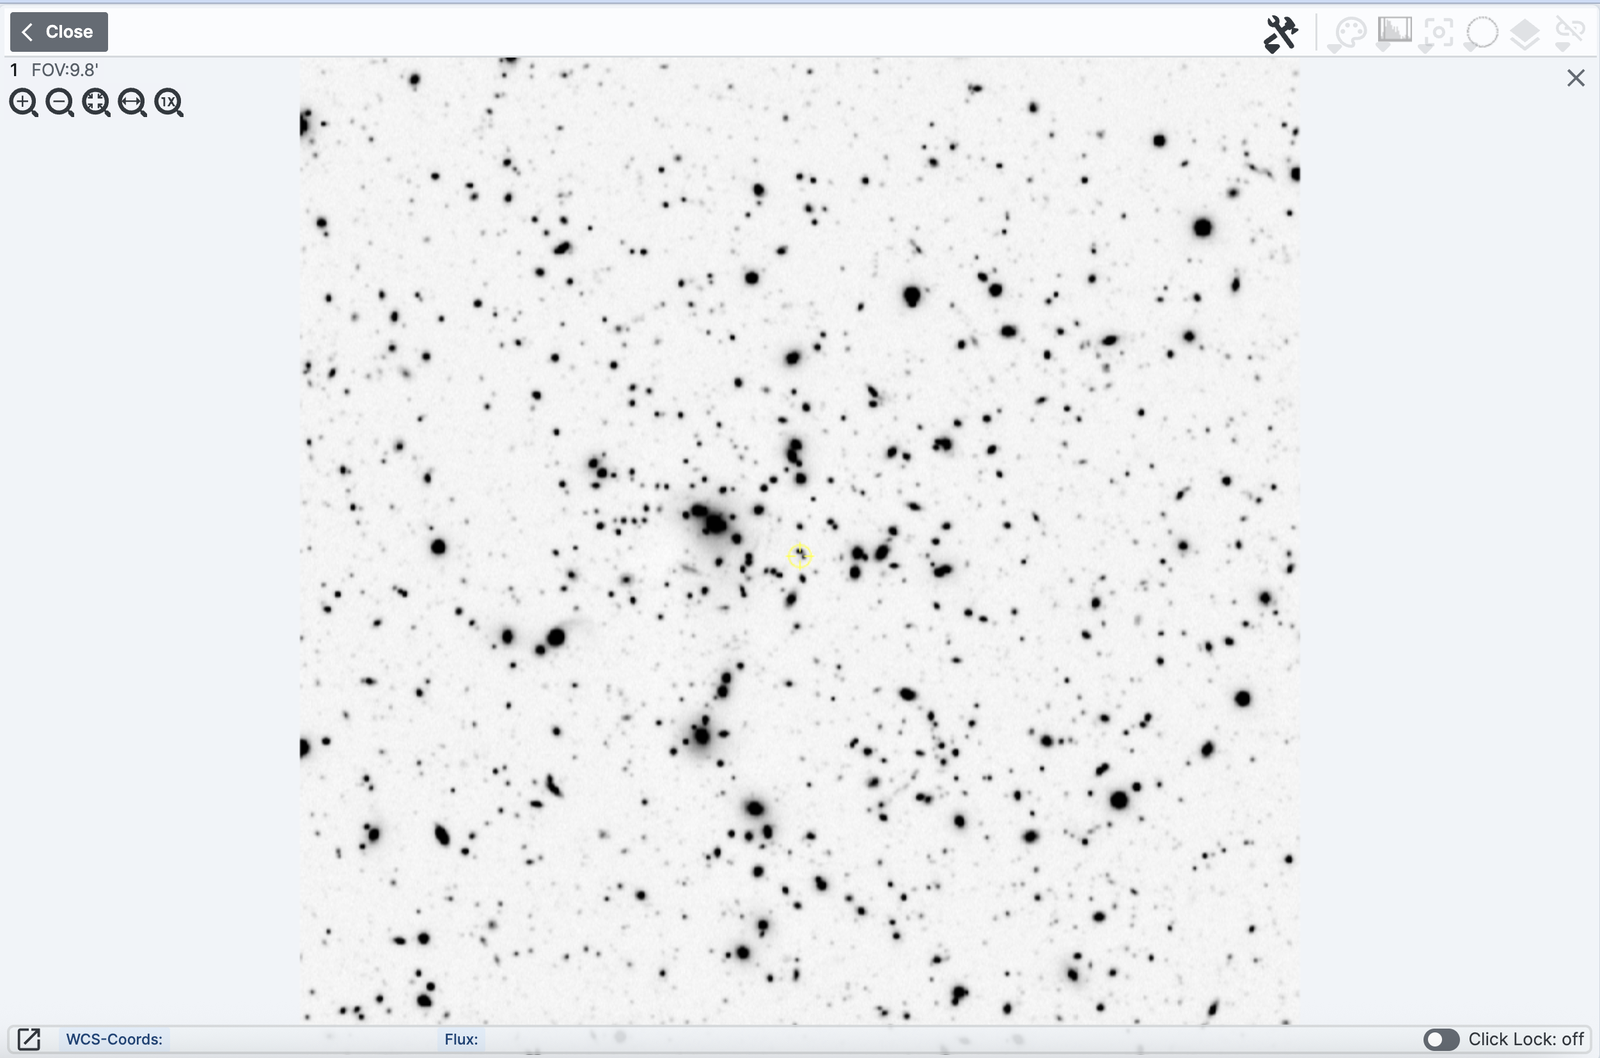

</div>

> **Figure 2:** The multi-patch cutout of PSZ2 G309.43-72.86 displayed in Firefly. Firefly uses the new WCS to show the image in celestial coordinates, and the mask plane has been set fully transparent so only the pixel data are shown.

### 4.3. Option to save as a FITS file

To save as a FITS file in the home directory, uncomment (remove the #)
from all lines in the following cell and then execute it.

> **Warning:** Images can take up a lot of disk space. Save and download with caution.

In [ ]:
# import os
# username = os.environ.get('USER')
# fnm = '/home/' + username + '/my_big_cutout_dp2_cluster.fits'
# new_image_i.template.writeFits(fnm)
# del username, fnm

## 5. Compare PSFs

Compare the Point Spread Function (PSF) of the new big coadd with that of the original `deep_coadd` associated with the cluster center, at the cluster center and at a second location offset from it, to illustrate the spatial variation of the PSF across the mosaic.

For the original `deep_coadd`, use the DP2 cell-coadd PSF and WCS interfaces (`deep_coadd.psf` and `deep_coadd.sky_projection`), as in the 205-series tutorial on the PSF for `deep_coadd` images.
The new big coadd is a legacy afw `Exposure` produced by `GetTemplateTask`, so its PSF is accessed with `getPsf`.
In both cases the PSF size is measured as the adaptive-moments sigma of the PSF stamp using `galsim`.

Get the original `deep_coadd` (as a cell coadd) and its PSF, WCS, and bounding box.

In [ ]:
bcg_coadd = butler.get(bcg_data_ref)
coadd_psf = bcg_coadd.psf
coadd_wcs = bcg_coadd.sky_projection
coadd_bbox = bcg_coadd.bbox

**Function**: `psf_sigma`

Measure the PSF size (the adaptive-moments sigma, in pixels) from a PSF postage-stamp image with `galsim`, following the 205-series PSF tutorial.

In [ ]:
def psf_sigma(psf_image_array):
    """Return the adaptive-moments sigma (in pixels) of a PSF stamp array."""
    gs_image = galsim.Image(np.ascontiguousarray(psf_image_array), scale=1.0)
    return galsim.hsm.FindAdaptiveMom(gs_image, guess_sig=3.0).moments_sigma

Define the two comparison locations.
The PSF is only defined where input images contribute, so the corners of the rectangular cutout may fall outside the data coverage.
To choose a location that is guaranteed to lie within both the original patch and the new mosaic, take the point halfway between the cluster center and the center of its patch (a bounding box is convex, so the midpoint of two interior points is also interior).

In [ ]:
center = SkyCoord(ra=ra_bcg * u.deg, dec=dec_bcg * u.deg)
center_xy = coadd_wcs.sky_to_pixel(center)

patch_center_x = 0.5 * (coadd_bbox.x.start + coadd_bbox.x.stop)
patch_center_y = 0.5 * (coadd_bbox.y.start + coadd_bbox.y.stop)
offset = coadd_wcs.pixel_to_sky(
    x=0.5 * (center_xy.x + patch_center_x),
    y=0.5 * (center_xy.y + patch_center_y))

locations = [("center", center), ("offset", offset)]

Loop over locations and compare the PSF Full Width at Half Maximum (FWHM) size for each one.

In [ ]:
SIGMA_TO_FWHM = 2.0 * np.sqrt(2.0 * np.log(2.0))
template_psf = new_image_i.template.getPsf()

for label, coord in locations:
    # Original deep_coadd PSF (DP2 cell-coadd API).
    xy = coadd_wcs.sky_to_pixel(coord)
    coadd_stamp = coadd_psf.compute_kernel_image(x=xy.x, y=xy.y)
    sigma_coadd = psf_sigma(coadd_stamp.array)

    # New big coadd PSF (legacy afw Exposure from GetTemplateTask).
    template_point = new_wcs.skyToPixel(
        SpherePoint(coord.ra.deg, coord.dec.deg, degrees))
    template_stamp = template_psf.computeKernelImage(template_point)
    sigma_template = psf_sigma(template_stamp.array)

    percent_diff = np.abs(sigma_coadd - sigma_template) / sigma_template * 100
    print(f"{label}: deep_coadd FWHM = {sigma_coadd * SIGMA_TO_FWHM: .3f} pixels, "
          f"new coadd FWHM = {sigma_template * SIGMA_TO_FWHM: .3f} pixels, "
          f"difference = {percent_diff: .2f}%")

The two PSF FWHM values agree to well within a percent at each location. This small, nonzero difference is expected: the new big coadd is not a copy of the original `deep_coadd` pixels, but a resampling of the input coadds onto the new discrete-skymap WCS. Warping to this new pixel grid interpolates the pixel values, which slightly alters the measured PSF even at the same sky coordinate. The sub-percent agreement therefore confirms that `GetTemplateTask` preserves the PSF to high accuracy when building the mosaic; a large difference, by contrast, would point to a problem with the warping or the input data.